### """
________________________________________________________________________________________________________________________

                                              INPE -     Trabalho de ICD - Trabalho 3
  
                                                  Sérgio Goulart - 2026
________________________________________________________________________________________________________________________
                                         
                                                       Featuretools
________________________________________________________________________________________________________________________
                                                        Versão 1.3
________________________________________________________________________________________________________________________
"""

"""
________________________________________________________________________________________________________________________
 Informações:

 https://docs.google.com/document/d/100VZ8SP9okyyXScmlKJw45Srq0z7r3qlepecxEAYwnY/edit?tab=t.0
 
 https://github.com/alteryx/featuretools/blob/main/featuretools/computational_backends/calculate_feature_matrix.py
________________________________________________________________________________________________________________________
"""


"""
 python -m pip install featuretools
 python -m pip install graphviz
 pip install featuretools graphviz
"""

In [1]:
# ======================================================================================================================
#                                           1. Instalação e Importação das Bibliotecas
# ======================================================================================================================
# !pip install featuretools pandas numpy
# !conda install -c conda-forge graphviz python-graphviz -y

import pandas as pd
import numpy as np
import featuretools as ft

import warnings
warnings.filterwarnings('ignore')


C:\Users\profs\anaconda3\Lib\site-packages\woodwork\__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


2026-08-12 08:23:31,179 featuretools - WARNING    While loading primitives via "premium_primitives" entry point, ignored primitive "DiversityScore" from "premium_primitives.diversity_score" because a primitive with that name already exists in "nlp_primitives.diversity_score"
2026-08-12 08:23:31,187 featuretools - WARNING    While loading primitives via "premium_primitives" entry point, ignored primitive "LSA" from "premium_primitives.lsa" because a primitive with that name already exists in "nlp_primitives.lsa"
2026-08-12 08:23:31,189 featuretools - WARNING    While loading primitives via "premium_primitives" entry point, ignored primitive "MeanCharactersPerSentence" from "premium_primitives.mean_characters_per_sentence" because a primitive with that name already exists in "nlp_primitives.mean_characters_per_sentence"
2026-08-12 08:23:31,195 featuretools - WARNING    While loading primitives via "premium_primitives" entry point, ignored primitive "NumberOfSentences" from "premium_primi

In [2]:
# ======================================================================================================================
#                                            2. Criação dos Dados com Datas Formatadas
# ======================================================================================================================
# Formato utilizado: '%Y/%m/%d' (Ano/Mês/Dia)

df_clientes = pd.DataFrame({
    'cliente_id': [1, 2, 3],
    'data_cadastro': pd.to_datetime(
        ['2023/01/10', '2023/02/15', '2023/03/01'], 
#?         format='%Y-%m-%d'
        format='%Y/%m/%d'
        
#?             format='%Y-%m-%d'

#? df['data'] = pd.to_datetime(df['data'], format='%d/%m/%Y')
        
    ),
    'cidade': ['São Paulo', 'Rio de Janeiro', 'Belo Horizonte']
})

print("___________________________________________________________________________________________________________\n")
print("                                             Clientes\n")
print("___________________________________________________________________________________________________________\n")

display(df_clientes)

df_transacoes = pd.DataFrame({
    'transacao_id': [101, 102, 103, 104, 105, 106],
    'cliente_id': [1, 1, 2, 2, 2, 3],
    'data_transacao': pd.to_datetime([
        '2023/01/12', '2023/01/15', '2023/02/20', 
        '2023/02/22', '2023/03/05', '2023/03/10'
    ], 
                                    
#?     format='%Y-%m-%d'),

#?         format='%Y-%m-%d'
        format='%Y/%m/%d'),
    
    
    'valor': [150.0, 300.5, 45.0, 200.0, 80.0, 500.0],
    'categoria': ['Eletrônicos', 'Roupas', 'Mercado', 'Eletrônicos', 'Roupas', 'Eletrônicos']
})

print("___________________________________________________________________________________________________________\n")
print("                                            Transações\n")
print("___________________________________________________________________________________________________________\n")

display(df_transacoes)

___________________________________________________________________________________________________________

                                             Clientes

___________________________________________________________________________________________________________



,cliente_id,data_cadastro,cidade
0,1,2023-01-10,São Paulo
1,2,2023-02-15,Rio de Janeiro
2,3,2023-03-01,Belo Horizonte


___________________________________________________________________________________________________________

                                            Transações

___________________________________________________________________________________________________________



,transacao_id,cliente_id,data_transacao,valor,categoria
0,101,1,2023-01-12,150.0,Eletrônicos
1,102,1,2023-01-15,300.5,Roupas
2,103,2,2023-02-20,45.0,Mercado
3,104,2,2023-02-22,200.0,Eletrônicos
4,105,2,2023-03-05,80.0,Roupas
5,106,3,2023-03-10,500.0,Eletrônicos


In [3]:
# ======================================================================================================================
#                                                 3. Construção do EntitySet
# ======================================================================================================================
es = ft.EntitySet(id="dados_vendas") 

# Adiciona o DataFrame de Clientes
es = es.add_dataframe(
    dataframe_name="clientes",
    dataframe=df_clientes,
    index="cliente_id",
    time_index="data_cadastro"
)

# Adiciona o DataFrame de Transações
es = es.add_dataframe(
    dataframe_name="transacoes",
    dataframe=df_transacoes,
    index="transacao_id",
    time_index="data_transacao"
)

# Relacionamento (1 Cliente -> N Transações)
es = es.add_relationship("clientes", "cliente_id", "transacoes", "cliente_id")

print("___________________________________________________________________________________________________________\n")
print("                         Características do conjunto de entidades Dados_vendas\n")
print("___________________________________________________________________________________________________________\n")

display(es)

print("\n")
print("___________________________________________________________________________________________________________\n")
print("                                             FeatureTools                                                  \n")
print("___________________________________________________________________________________________________________\n")


display(ft)

___________________________________________________________________________________________________________

                         Características do conjunto de entidades Dados_vendas

___________________________________________________________________________________________________________



Entityset: dados_vendas
  DataFrames:
    clientes [Rows: 3, Columns: 3]
    transacoes [Rows: 6, Columns: 5]
  Relationships:
    transacoes.cliente_id -> clientes.cliente_id



___________________________________________________________________________________________________________

                                             FeatureTools                                                  

___________________________________________________________________________________________________________



<module 'featuretools' from 'C:\\Users\\profs\\anaconda3\\Lib\\site-packages\\featuretools\\__init__.py'>

In [4]:
# ======================================================================================================================
#                                                4. Engenharia de Features (DFS)
# ======================================================================================================================
feature_matrix, feature_defs = ft.dfs(
    entityset=es,
    target_dataframe_name="clientes",
    max_depth=2
)

# Exibe o resultado final com a tipagem correta de datetime
display(feature_matrix.head())

,COUNT(transacoes),MAX(transacoes.valor),MEAN(transacoes.valor),MIN(transacoes.valor),SKEW(transacoes.valor),STD(transacoes.valor),SUM(transacoes.valor),DAY(data_cadastro),MONTH(data_cadastro),WEEKDAY(data_cadastro),YEAR(data_cadastro),MODE(transacoes.DAY(data_transacao)),MODE(transacoes.MONTH(data_transacao)),MODE(transacoes.WEEKDAY(data_transacao)),MODE(transacoes.YEAR(data_transacao)),NUM_UNIQUE(transacoes.DAY(data_transacao)),NUM_UNIQUE(transacoes.MONTH(data_transacao)),NUM_UNIQUE(transacoes.WEEKDAY(data_transacao)),NUM_UNIQUE(transacoes.YEAR(data_transacao))
cliente_id,,,,,,,,,,,,,,,,,,,
1,2,300.5,225.250000,150.0,NaN,106.419571,450.5,10,1,1,2023,12,1,3,2023,2,1,2,1
2,3,200.0,108.333333,45.0,1.377895,81.291656,325.0,15,2,2,2023,5,2,0,2023,3,2,3,1
3,1,500.0,500.000000,500.0,NaN,NaN,500.0,1,3,2,2023,10,3,4,2023,1,1,1,1


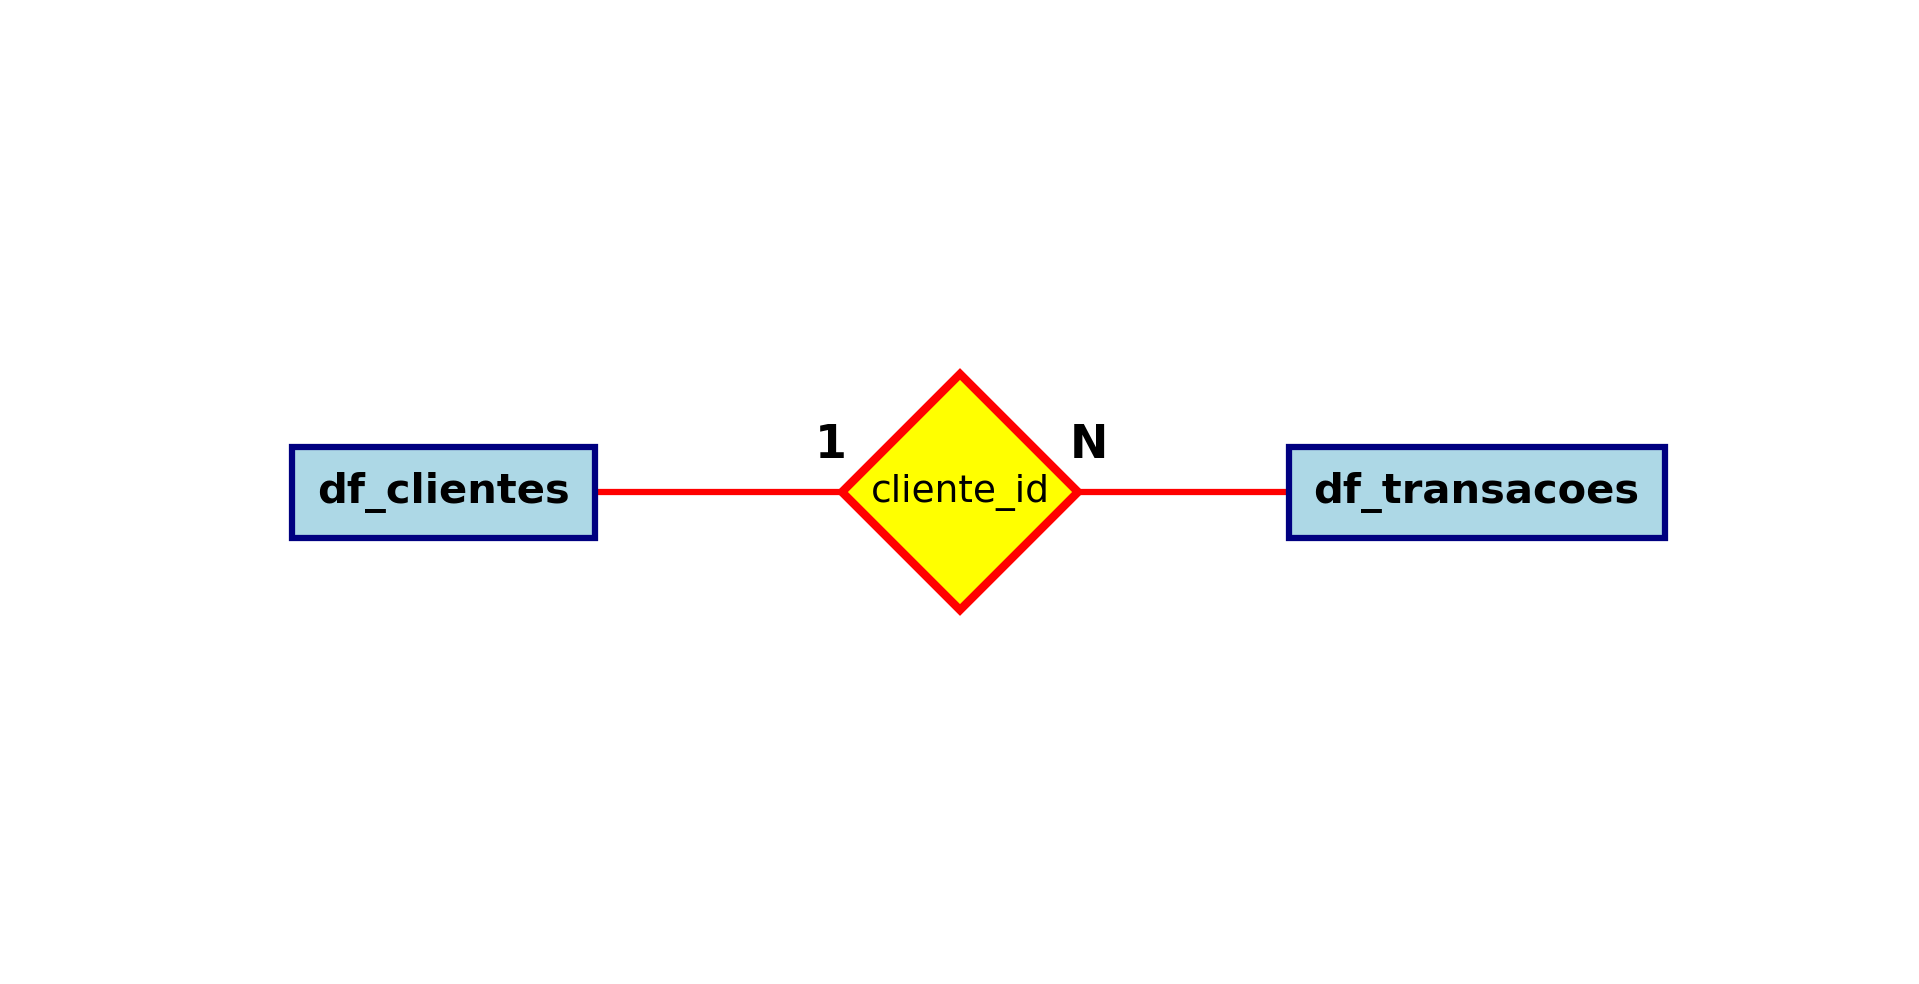

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import Image, display

G = nx.Graph()
# Adiciona relações baseadas nas chaves coincidentes
G.add_edge('df_clientes', 'df_transacoes', label='cliente_id')

# Define as posições manualmente para forçar o alinhamento horizontal
pos = {
    'df_clientes': (-1.0, 0.0),    
    'df_transacoes': (1.0, 0.0)    
}

# Configura a figura do matplotlib
plt.figure(figsize=(8, 4))

# 1. Desenha as arestas (linhas)
nx.draw_networkx_edges(G, pos, edge_color='red', width=1.5)

# 2. Desenha o LOSANGO vermelho no centro da linha
x_centro = 0.0
y_centro = 0.0

plt.plot(
    x_centro, y_centro, 
    marker='D',            
    markersize=40,         
    markerfacecolor='yellow', 
    markeredgecolor='red', 
    markeredgewidth=2
)

# Insere o texto da chave exatamente no centro do losango
plt.text(
    x_centro, y_centro, 
    s='cliente_id', 
    ha='center', 
    va='center', 
    fontsize=9, 
    color='black',
    fontweight='medium'
)

# 3. Adiciona as cardinalidades (1 à esquerda e N à direita do losango)
# Afasta as anotações do centro decrementando e incrementando a coordenada X
plt.text(x_centro - 0.25, y_centro + 0.05, s='1', ha='center', va='center', fontsize=11, fontweight='bold', color='black')
plt.text(x_centro + 0.25, y_centro + 0.05, s='N', ha='center', va='center', fontsize=11, fontweight='bold', color='black')

# 4. Desenha os nós como retângulos padrão
for node, (x, y) in pos.items():
    plt.text(
        x, y, 
        s=node, 
        ha='center', 
        va='center', 
        fontsize=10, 
        fontweight='bold',
        bbox=dict(
            boxstyle='square,pad=0.6',  
            facecolor='lightblue',       
            edgecolor='navy',            
            linewidth=1.5   
        )
    )

# Ajusta os limites dos eixos
ax = plt.gca()
ax.set_xlim(-1.8, 1.8)
ax.set_ylim(-0.5, 0.5)
plt.axis('off')

# Nome do arquivo de saída
#? nome_arquivo = 'diagrama_er.png'

# Nome do arquivo de saída
nome_arquivo = 'C:/Users/profs/ICD_Trabalho_03_Seminarios_FeatureTools/diagrama_er.png'

# 5. Salva a imagem em formato PNG
plt.savefig(
    nome_arquivo, 
    dpi=300,              
    bbox_inches='tight',  
    transparent=False,     
    facecolor='white'
)

plt.close()

# 6. Abre e exibe o arquivo PNG salvo
display(Image(filename=nome_arquivo))
